# Predicting Stock Prices With RNNs

Approach:
- Using stock prices from the Energy industry (Tickers: COP, CVX, DVN, SHEL, SLB, XOM)
- Predicting log returns rather than price for the statistical benefits of a stationary time series and homoskedasticity
- Also using FRED macroeconomic data for added predictive power (hopefully)
- Testing out RNN, LSTM, GRU models on the data, different windows, etc.


## Preprocessing

In [55]:
import pandas as pd

cop = pd.read_csv("../datasets/energy_stock_data/cop.us.txt")
cvx = pd.read_csv("../datasets/energy_stock_data/cvx.us.txt")
dvn = pd.read_csv("../datasets/energy_stock_data/dvn.us.txt")
slb = pd.read_csv("../datasets/energy_stock_data/slb.us.txt")
xom = pd.read_csv("../datasets/energy_stock_data/xom.us.txt")


In [56]:
import os
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv()
fred_key = os.getenv("FRED_KEY")
f = Fred(fred_key)

series_ids = {
    'unemployment': 'UNRATE',
    'cpi': 'CPIAUCSL',
    'gasoline': 'GASREGCOVW',
    'fed_funds': 'FEDFUNDS',
}


dfs = []
for name, sid in series_ids.items():
    releases = f.get_series_all_releases(sid)
    first_release = releases.groupby('date').first().reset_index()
    first_release = first_release.rename(columns={'value': name, 'realtime_start': f'{name}_release_date'})
    first_release = first_release.set_index('date')
    dfs.append(first_release)

macro = pd.concat(dfs, axis=1)
macro = macro.resample('MS').last()
macro.index = pd.to_datetime(macro.index)

/tmp/ipykernel_80505/1476875359.py:25: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  macro = pd.concat(dfs, axis=1)


In [57]:
tickers = {'cop': cop, 'cvx': cvx, 'dvn': dvn, 'slb': slb, 'xom': xom}

dfs = []
for name, df in tickers.items():
    tmp = df[['<DATE>', '<CLOSE>', '<VOL>']].copy()
    tmp.columns = ['date', f'{name}_close', f'{name}_vol']
    tmp['date'] = pd.to_datetime(tmp['date'], format='%Y%m%d')
    tmp = tmp.set_index('date')
    dfs.append(tmp)

combined = pd.concat(dfs, axis=1)
combined = combined.dropna()
combined.reset_index(inplace=True)
combined['date'] = pd.to_datetime(combined['date'])
combined = combined.sort_values('date')
macro_reset = macro[['unemployment', 'cpi', 'gasoline', 'fed_funds']].reset_index().sort_values('date')

combined = pd.merge_asof(combined, macro_reset, on='date', direction='backward', allow_exact_matches=False)

/tmp/ipykernel_80505/1602370429.py:11: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(dfs, axis=1)


In [58]:
combined[["unemployment", "cpi", "gasoline", "fed_funds"]] = combined[["unemployment", "cpi", "gasoline", "fed_funds"]].ffill(inplace=False)

In [59]:
import numpy as np
import matplotlib.pyplot as plt
combined_clean = combined.ffill().loc[combined.date > "2000-01-01"]

combined_clean["cop_ret_dir"] = ((combined_clean.cop_close).diff() > 0).astype(int)
combined_clean["cvx_ret_dir"] = ((combined_clean.cvx_close).diff() > 0).astype(int)
combined_clean["dvn_ret_dir"] = ((combined_clean.dvn_close).diff() > 0).astype(int)
combined_clean["slb_ret_dir"] = ((combined_clean.slb_close).diff() > 0).astype(int)
combined_clean["xom_ret_dir"] = ((combined_clean.xom_close).diff() > 0).astype(int)

combined_clean["cop_log_ret"] = np.log(combined_clean.cop_close).diff()
combined_clean["cvx_log_ret"] = np.log(combined_clean.cvx_close).diff()
combined_clean["dvn_log_ret"] = np.log(combined_clean.dvn_close).diff()
combined_clean["slb_log_ret"] = np.log(combined_clean.slb_close).diff()
combined_clean["xom_log_ret"] = np.log(combined_clean.xom_close).diff()

tickers = ['cop', 'cvx', 'dvn', 'slb', 'xom']
macro_cols = ['unemployment', 'cpi', 'gasoline', 'fed_funds']

for t in tickers:
    combined_clean[f'{t}_ret_dir'] = combined_clean[f'{t}_ret_dir'].shift(-1)

combined_clean = combined_clean.iloc[:-1]
combined_clean = combined_clean.drop(columns=[f'{t}_close' for t in tickers])

for t in tickers:
    combined_clean[f'{t}_vol'] = np.log1p(combined_clean[f'{t}_vol'])

combined_clean = combined_clean.dropna().reset_index(drop=True)

In [60]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class StockDataset(Dataset):
    def __init__(self, df, tickers, macro_cols, seq_len=200):
        self.seq_len = seq_len
        self.samples = []

        macro = df[macro_cols].values

        for i, t in enumerate(tickers):
            feat_cols = [f'{t}_log_ret', f'{t}_vol']
            feats = df[feat_cols].values

            x = np.concatenate([feats, macro], axis=1).astype(np.float32)
            y = df[f'{t}_ret_dir'].values.astype(np.int64)

            for start in range(len(df) - seq_len):
                self.samples.append((
                    x[start:start + seq_len],
                    y[start + seq_len - 1]                    
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x), torch.tensor(y)

In [61]:
n = len(combined_clean)
train_df = combined_clean.iloc[:int(n * 0.7)]
val_df = combined_clean.iloc[int(n * 0.7):]
# test_df = combined_clean.iloc[int(n * 0.85):]

sequence_length = 100 

train_ds = StockDataset(train_df.reset_index(drop=True), tickers, macro_cols, seq_len=sequence_length)
val_ds = StockDataset(val_df.reset_index(drop=True), tickers, macro_cols, seq_len=sequence_length)
# test_ds = StockDataset(test_df.reset_index(drop=True), tickers, macro_cols, seq_len=sequence_length)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
# test_loader = DataLoader(test_ds, batch_size=32)

#### Train, Eval Functions

In [62]:
device = "cuda"

def train(model, data_loader, loss_fn, optimizer, metric, epochs):
    model.train()
    metrics = []
    for epoch in range(epochs):
      epoch_metrics = []
      for X_train, y_train in data_loader:
        X_train = X_train.to(device)
        y_train = y_train.to(device)
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_metrics.append(metric(y_pred, y_train).item())
      metrics.append(sum(epoch_metrics)/len(epoch_metrics))
    return metrics

def validate(model, data_loader, loss_fn, metric):
    model.eval()
    validation_losses = []
    validation_metrics = []
    with torch.no_grad():
        for X_val, y_val in data_loader:
            X_val = X_val.to(device)
            y_val = y_val.to(device)
            y_pred = model(X_val)
            loss = loss_fn(y_pred, y_val)
            validation_losses.append(loss.item())
            validation_metrics.append(metric(y_pred, y_val).item())
    return sum(validation_losses) / len(validation_losses), sum(validation_metrics) / len(validation_metrics)

## Deep RNN

In [63]:
import torch.nn as nn
import torchmetrics

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, 2)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.output(out)
        return out
    
model = RNNModel(input_size=6, hidden_size=100, num_layers=5).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
metric = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)
train(model, train_loader, loss_fn, optimizer, metric, epochs=10)
eval_loss, val_acc = validate(model, val_loader, loss_fn, metric)
print(f"Validation Accuracy: {val_acc:.4f}")

Validation Accuracy: 0.4888


## LSTM

In [64]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.output(out)
        return out

model = LSTMModel(input_size=6, hidden_size=100, num_layers=5).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
metric = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)
train(model, train_loader, loss_fn, optimizer, metric, epochs=10)
eval_loss, val_acc = validate(model, val_loader, loss_fn, metric)
print(f"Validation Accuracy: {val_acc:.4f}")

Validation Accuracy: 0.5112


## GRU

In [66]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, 2)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.output(out)
        return out

model = GRUModel(input_size=6, hidden_size=200, num_layers=3).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
metric = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)
train(model, train_loader, loss_fn, optimizer, metric, epochs=10)
eval_loss, val_acc = validate(model, val_loader, loss_fn, metric)
print(f"Validation Accuracy: {val_acc:.4f}")

Validation Accuracy: 0.5112


Looks like predicting stocks with these basic RNNs and the limited data we chose is hard. This makes sense: if you've ever taken a time series analysis class, you may be familiar with the difficulties in predicting white noise:

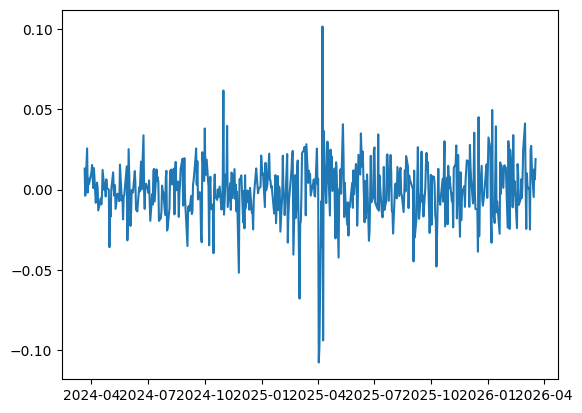

In [70]:
xvals = combined_clean.date[-500:]
yvals = combined_clean.cop_log_ret[-500:]
plt.plot(xvals, yvals)

While this doesn't look like completely random white noise, it looks close to it. Getting any signal from this is the job of many smart people at trading firms.